# Clasificación de Área mediante Transformers (PLN Avanzado)

Fine-tuning de modelos pre-entrenados de tipo **Transformer** para clasificar transacciones bancarias según su **Área** a partir de la descripción textual (en español).

## Modelos entrenados
| Modelo | HuggingFace ID | Tipo |
|--------|---------------|------|
| BETO | `dccuchile/bert-base-spanish-wwm-cased` | Monolingüe ES |
| RoBERTa-BNE | `PlanTL-GOB-ES/roberta-base-bne` | Monolingüe ES |
| BERTIN | `bertin-project/bertin-roberta-base-spanish` | Monolingüe ES |
| XLM-RoBERTa | `xlm-roberta-base` | Multilingüe |
| DistilBERT Multi | `distilbert-base-multilingual-cased` | Multilingüe |

## 1. Instalación de Dependencias

Ejecutar solo si no están instaladas.

In [4]:
# Descomentar y ejecutar si es necesario:
# !pip install transformers datasets accelerate torch scikit-learn matplotlib seaborn sentencepiece

## 2. Importaciones y Configuración

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time
import torch
from collections import OrderedDict

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Librerias cargadas")
print(f"Dispositivo: {DEVICE}")
if DEVICE == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

Librerias cargadas
Dispositivo: cpu


## 3. Carga y Preparación de Datos

In [6]:
DATA_PATH = os.path.join("..", "data", "processed", "db_mod_descript_train.csv")
df_raw = pd.read_csv(DATA_PATH)

df = df_raw[["Description", "Area"]].copy().dropna()

print(f"Dataset: {df.shape[0]} filas")
print(f"Clases unicas de Area: {df['Area'].nunique()}")
print()
print(df["Area"].value_counts())
df.head()

Dataset: 442 filas
Clases unicas de Area: 9

Area
Invoice               120
Food                   88
Leisure                87
Deposit                44
Salary                 41
Investment             36
Food, Vacations        10
Leisure, Vacations      9
Invoice, Vacations      7
Name: count, dtype: int64


,Description,Area
0,Transferencia recibida de María por Bizum.,Deposit
1,Inversión mensual en acciones de Apple,Investment
2,Factura de Netflix domiciliada en cuenta,Invoice
3,Cesta de la compra básica en el Lidl registrad...,Food
4,Operación de compra de activos en Bitcoin - pa...,Investment


In [7]:
# Codificar etiquetas
le = LabelEncoder()
df["label"] = le.fit_transform(df["Area"])

NUM_LABELS = len(le.classes_)
label2id = {label: idx for idx, label in enumerate(le.classes_)}
id2label = {idx: label for label, idx in label2id.items()}

print(f"Mapping de etiquetas ({NUM_LABELS} clases):")
for idx, label in id2label.items():
    print(f"  {idx} -> {label}")

Mapping de etiquetas (9 clases):
  0 -> Deposit
  1 -> Food
  2 -> Food, Vacations
  3 -> Investment
  4 -> Invoice
  5 -> Invoice, Vacations
  6 -> Leisure
  7 -> Leisure, Vacations
  8 -> Salary


In [8]:
# Split 80/20 estratificado
df_train, df_test = train_test_split(
    df, test_size=0.20, random_state=SEED, stratify=df["label"]
)

print(f"Division estratificada 80/20:")
print(f"  Train: {len(df_train)} muestras")
print(f"  Test:  {len(df_test)} muestras")

train_dataset = Dataset.from_pandas(df_train[["Description", "label"]].reset_index(drop=True))
test_dataset = Dataset.from_pandas(df_test[["Description", "label"]].reset_index(drop=True))

print(f"\nDatasets HF creados: train={len(train_dataset)}, test={len(test_dataset)}")

Division estratificada 80/20:
  Train: 353 muestras
  Test:  89 muestras

Datasets HF creados: train=353, test=89


## 4. Definición de Modelos e Hiperparámetros

In [9]:
MODELS = OrderedDict({
    "BETO": "dccuchile/bert-base-spanish-wwm-cased",
    "RoBERTa-BNE": "PlanTL-GOB-ES/roberta-base-bne",
    "XLM-RoBERTa": "xlm-roberta-base",
    "DistilBERT Multi": "distilbert-base-multilingual-cased",
    "BERTIN": "bertin-project/bertin-roberta-base-spanish",
})

MAX_LENGTH = 64
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

print(f"{len(MODELS)} modelos a entrenar:")
for name, model_id in MODELS.items():
    print(f"  - {name}: {model_id}")

print(f"\nHiperparametros:")
print(f"  max_length={MAX_LENGTH}, batch_size={BATCH_SIZE}, epochs={EPOCHS}")
print(f"  lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY}")

5 modelos a entrenar:
  - BETO: dccuchile/bert-base-spanish-wwm-cased
  - RoBERTa-BNE: PlanTL-GOB-ES/roberta-base-bne
  - XLM-RoBERTa: xlm-roberta-base
  - DistilBERT Multi: distilbert-base-multilingual-cased
  - BERTIN: bertin-project/bertin-roberta-base-spanish

Hiperparametros:
  max_length=64, batch_size=16, epochs=3
  lr=2e-05, weight_decay=0.01


## 5. Función de Métricas

In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_weighted": f1_score(labels, predictions, average="weighted"),
        "precision_weighted": precision_score(labels, predictions, average="weighted"),
        "recall_weighted": recall_score(labels, predictions, average="weighted"),
    }

print("Funcion de metricas definida")

Funcion de metricas definida


## 6. Función de Entrenamiento (Fine-Tuning)

In [11]:
def train_transformer(model_name, model_id, train_ds, test_ds, num_labels, epochs=EPOCHS):
    """
    Fine-tuning de un modelo transformer para clasificacion de secuencias.
    Usa trainer.predict() en lugar de trainer.evaluate() para evitar
    el bug 'on_train_begin must be called before on_evaluate'.
    """
    print(f"\n{'='*60}")
    print(f"Entrenando: {model_name} ({model_id})")
    print(f"{'='*60}")

    # 1. Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_id)

    def tokenize_fn(examples):
        return tokenizer(
            examples["Description"],
            padding="max_length",
            truncation=True,
            max_length=MAX_LENGTH,
        )

    train_tok = train_ds.map(tokenize_fn, batched=True, remove_columns=["Description"])
    test_tok = test_ds.map(tokenize_fn, batched=True, remove_columns=["Description"])
    train_tok.set_format("torch")
    test_tok.set_format("torch")

    # 2. Modelo
    model = AutoModelForSequenceClassification.from_pretrained(
        model_id,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )

    # 3. Training args
    output_dir = f"./results_{model_name.lower().replace(' ', '_')}"

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,
        logging_steps=10,
        seed=SEED,
        report_to="none",
        fp16=torch.cuda.is_available(),
    )

    # 4. Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        compute_metrics=compute_metrics,
    )

    # 5. Entrenar
    trainer.train()

    # 6. Evaluar con predict (evita bug de evaluate tras load_best_model_at_end)
    preds_output = trainer.predict(test_tok)
    y_pred = np.argmax(preds_output.predictions, axis=-1)
    metrics = preds_output.metrics

    eval_results = {
        "eval_accuracy": metrics["test_accuracy"],
        "eval_f1_weighted": metrics["test_f1_weighted"],
        "eval_precision_weighted": metrics["test_precision_weighted"],
        "eval_recall_weighted": metrics["test_recall_weighted"],
    }

    print(f"\nResultados en test:")
    print(f"  Accuracy:  {eval_results['eval_accuracy']:.4f}")
    print(f"  F1:        {eval_results['eval_f1_weighted']:.4f}")
    print(f"  Precision: {eval_results['eval_precision_weighted']:.4f}")
    print(f"  Recall:    {eval_results['eval_recall_weighted']:.4f}")

    return {
        "trainer": trainer,
        "tokenizer": tokenizer,
        "eval_results": eval_results,
        "y_pred": y_pred,
        "model": model,
    }

print("Funcion de entrenamiento definida")

Funcion de entrenamiento definida


## 7. Entrenamiento de Todos los Modelos

> **Nota:** El entrenamiento de 5 modelos puede tardar varios minutos en CPU.

In [12]:
all_results = {}
training_times = {}

for model_name, model_id in MODELS.items():
    start = time.time()
    try:
        result = train_transformer(
            model_name, model_id, train_dataset, test_dataset, NUM_LABELS
        )
        all_results[model_name] = result
        training_times[model_name] = time.time() - start
        print(f"Tiempo: {training_times[model_name]:.1f}s")
    except Exception as e:
        print(f"Error entrenando {model_name}: {e}")
        training_times[model_name] = time.time() - start

print(f"\n{'='*60}")
print(f"Entrenamiento completado: {len(all_results)}/{len(MODELS)} modelos")
print(f"{'='*60}")


Entrenando: BETO (dccuchile/bert-base-spanish-wwm-cased)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 18263.51it/s]
BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECT

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Weighted,Recall Weighted
1,1.421561,1.017512,0.685393,0.614731,0.601862,0.685393
2,0.732071,0.456845,0.943820,0.917293,0.893497,0.943820
3,0.454586,0.310181,0.988764,0.983477,0.978777,0.988764


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.88it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer


Resultados en test:
  Accuracy:  0.9888
  F1:        0.9835
  Precision: 0.9788
  Recall:    0.9888
Tiempo: 315.1s

Entrenando: RoBERTa-BNE (PlanTL-GOB-ES/roberta-base-bne)
Error entrenando RoBERTa-BNE: Couldn't instantiate the backend tokenizer from one of: 
(1) a `tokenizers` library serialization file, 
(2) a slow tokenizer instance to convert or 
(3) an equivalent slow tokenizer class to instantiate and convert. 
You need to have sentencepiece or tiktoken installed to convert a slow tokenizer to a fast one.

Entrenando: XLM-RoBERTa (xlm-roberta-base)


...


Resultados en test:
  Accuracy:  0.7191
  F1:        0.6246
  Precision: 0.5630
  Recall:    0.7191
Tiempo: 227.3s

Entrenando: BERTIN (bertin-project/bertin-roberta-base-spanish)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4368.90it/s]
RobertaForSequenceClassification LOAD REPORT from: bertin-project/bertin-roberta-base-spanish
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Weighted,Recall Weighted
1,1.663045,1.344503,0.696629,0.594330,0.575601,0.696629
2,1.010832,0.826085,0.853933,0.815315,0.827780,0.853933
3,0.698918,0.587010,0.887640,0.868538,0.880429,0.887640


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.49it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la


Resultados en test:
  Accuracy:  0.8876
  F1:        0.8685
  Precision: 0.8804
  Recall:    0.8876
Tiempo: 305.9s

Entrenamiento completado: 4/5 modelos


## 8. Comparativa de Modelos

In [13]:
# Tabla resumen
results_list = []

for model_name, res in all_results.items():
    ev = res["eval_results"]
    results_list.append({
        "Modelo": model_name,
        "HF ID": MODELS[model_name],
        "Test Accuracy": ev["eval_accuracy"],
        "Test F1": ev["eval_f1_weighted"],
        "Test Precision": ev["eval_precision_weighted"],
        "Test Recall": ev["eval_recall_weighted"],
        "Tiempo (s)": training_times[model_name],
    })

df_results = pd.DataFrame(results_list).sort_values("Test F1", ascending=False)
df_results.index = range(1, len(df_results) + 1)

print("TABLA COMPARATIVA DE MODELOS TRANSFORMER:\n")
display(df_results.style.format({
    "Test Accuracy": "{:.4f}",
    "Test F1": "{:.4f}",
    "Test Precision": "{:.4f}",
    "Test Recall": "{:.4f}",
    "Tiempo (s)": "{:.1f}",
}).highlight_max(subset=["Test F1", "Test Accuracy"], color="#a8e6cf")
 .highlight_min(subset=["Tiempo (s)"], color="#a8e6cf"))

TABLA COMPARATIVA DE MODELOS TRANSFORMER:



,Modelo,HF ID,Test Accuracy,Test F1,Test Precision,Test Recall,Tiempo (s)
1,BETO,dccuchile/bert-base-spanish-wwm-cased,0.9888,0.9835,0.9788,0.9888,315.1
2,BERTIN,bertin-project/bertin-roberta-base-spanish,0.8876,0.8685,0.8804,0.8876,305.9
3,DistilBERT Multi,distilbert-base-multilingual-cased,0.7191,0.6246,0.5630,0.7191,227.3
4,XLM-RoBERTa,xlm-roberta-base,0.6742,0.5586,0.4919,0.6742,472.9


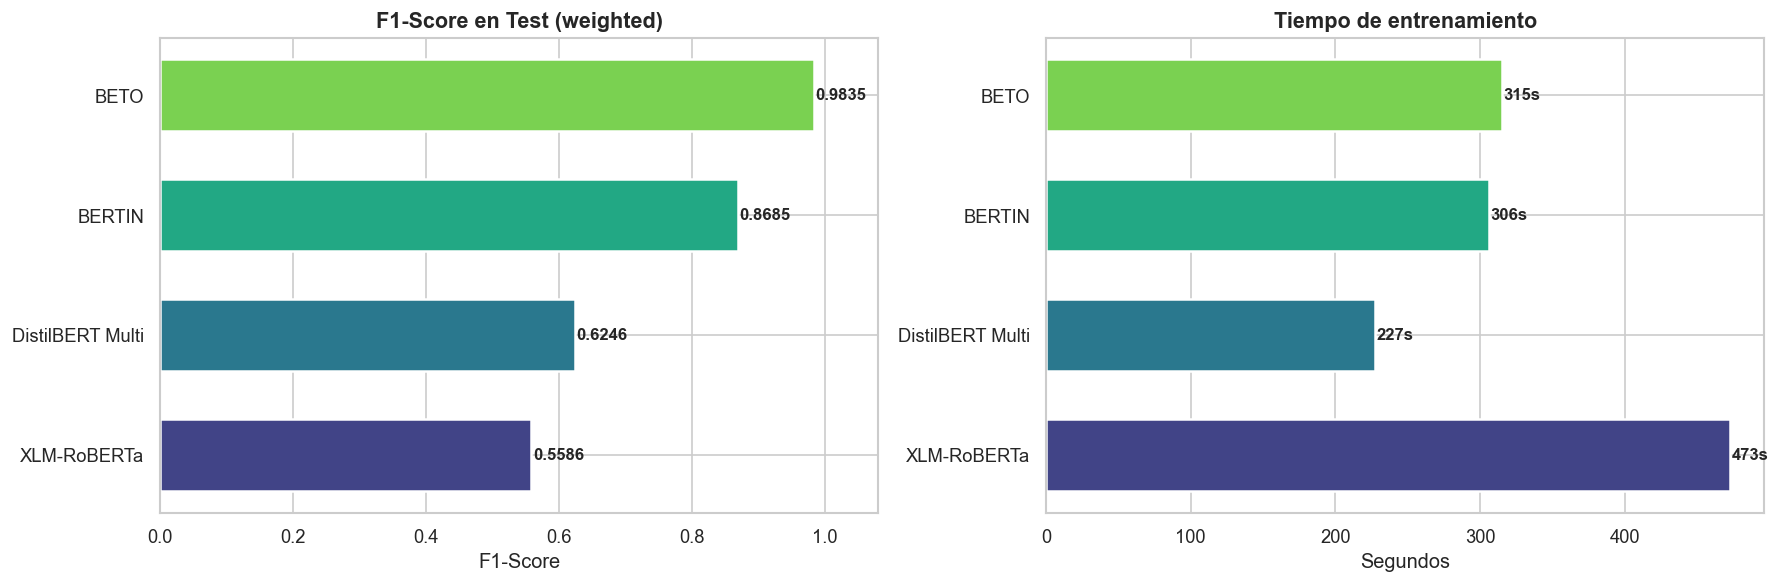

Grafico guardado: resultados_transformers.png


In [14]:
# Grafico comparativo: F1 y tiempo
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df_sorted = df_results.sort_values("Test F1", ascending=True)
palette = sns.color_palette("viridis", n_colors=len(df_sorted))

# F1 Score
bars = axes[0].barh(
    df_sorted["Modelo"], df_sorted["Test F1"],
    color=palette, edgecolor="white", linewidth=1.5, height=0.6,
)
for bar, val in zip(bars, df_sorted["Test F1"]):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                 f"{val:.4f}", va="center", fontsize=10, fontweight="bold")
axes[0].set_xlim(0, 1.08)
axes[0].set_title("F1-Score en Test (weighted)", fontweight="bold", fontsize=13)
axes[0].set_xlabel("F1-Score")

# Tiempo
bars2 = axes[1].barh(
    df_sorted["Modelo"], df_sorted["Tiempo (s)"],
    color=palette, edgecolor="white", linewidth=1.5, height=0.6,
)
for bar, val in zip(bars2, df_sorted["Tiempo (s)"]):
    axes[1].text(val + 1, bar.get_y() + bar.get_height() / 2,
                 f"{val:.0f}s", va="center", fontsize=10, fontweight="bold")
axes[1].set_title("Tiempo de entrenamiento", fontweight="bold", fontsize=13)
axes[1].set_xlabel("Segundos")

plt.tight_layout()
plt.savefig("resultados_transformers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico guardado: resultados_transformers.png")

## 9. Matrices de Confusión

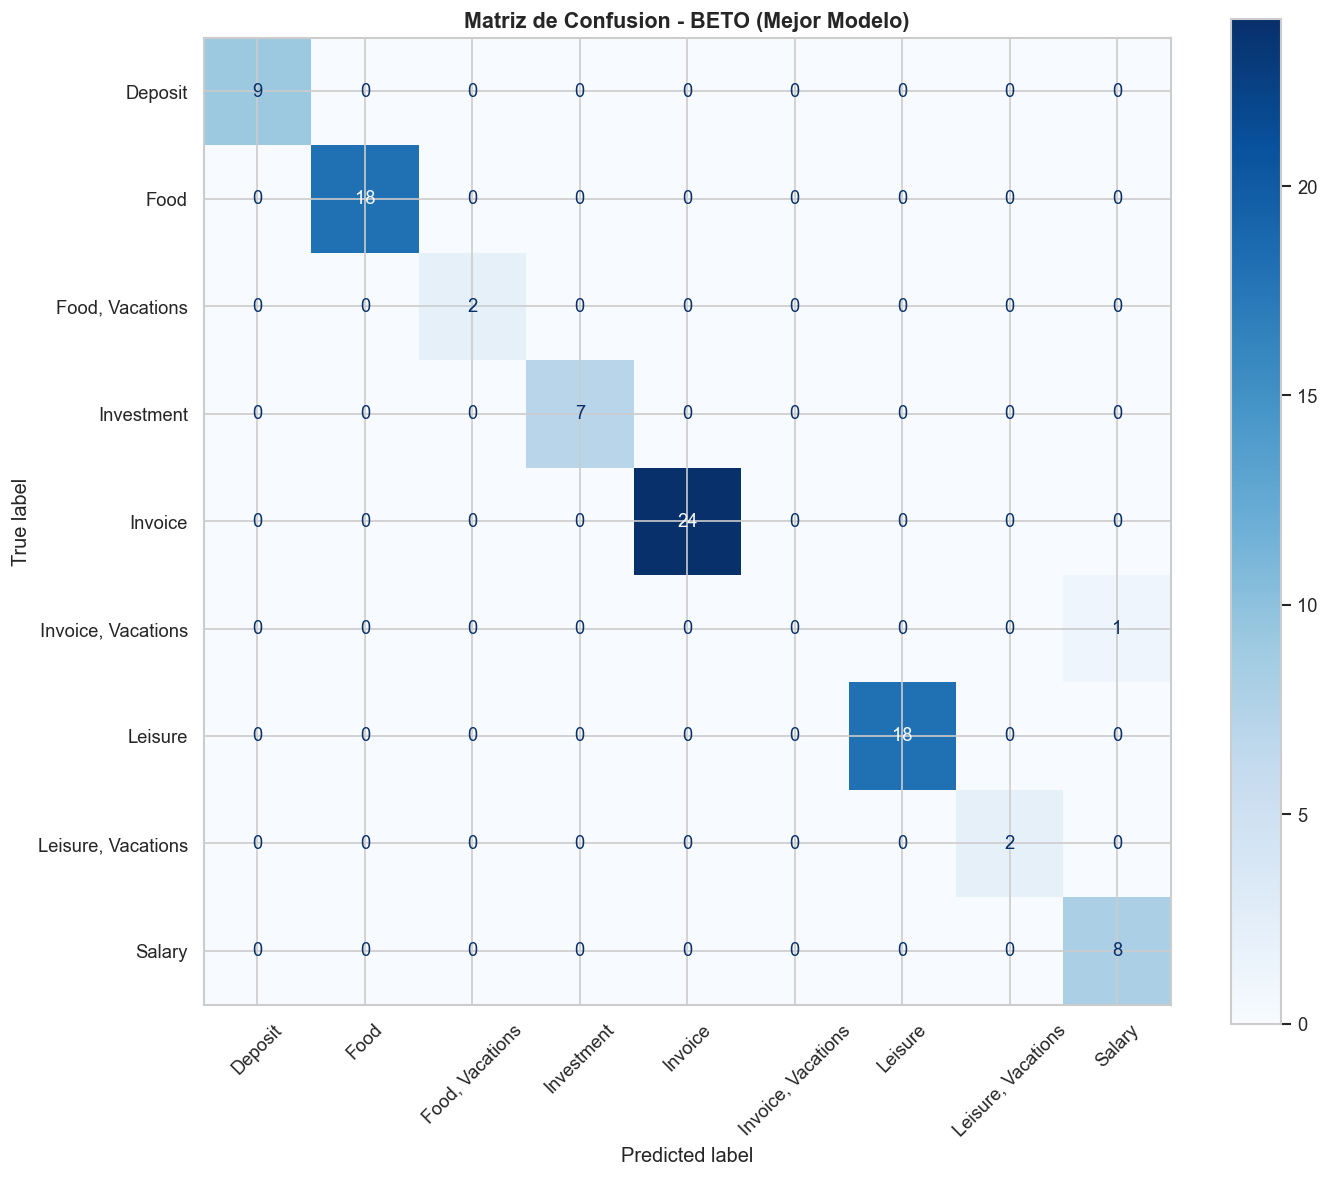

In [15]:
y_true = df_test["label"].values
labels_sorted = sorted(id2label.keys())
label_names = [id2label[i] for i in labels_sorted]

# Mejor modelo
best_name = df_results.iloc[0]["Modelo"]
best_result = all_results[best_name]
y_pred_best = best_result["y_pred"]

fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred_best, labels=labels_sorted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=True, xticks_rotation=45)
ax.set_title(f"Matriz de Confusion - {best_name} (Mejor Modelo)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("matriz_confusion_transformers_best.png", dpi=150, bbox_inches="tight")
plt.show()

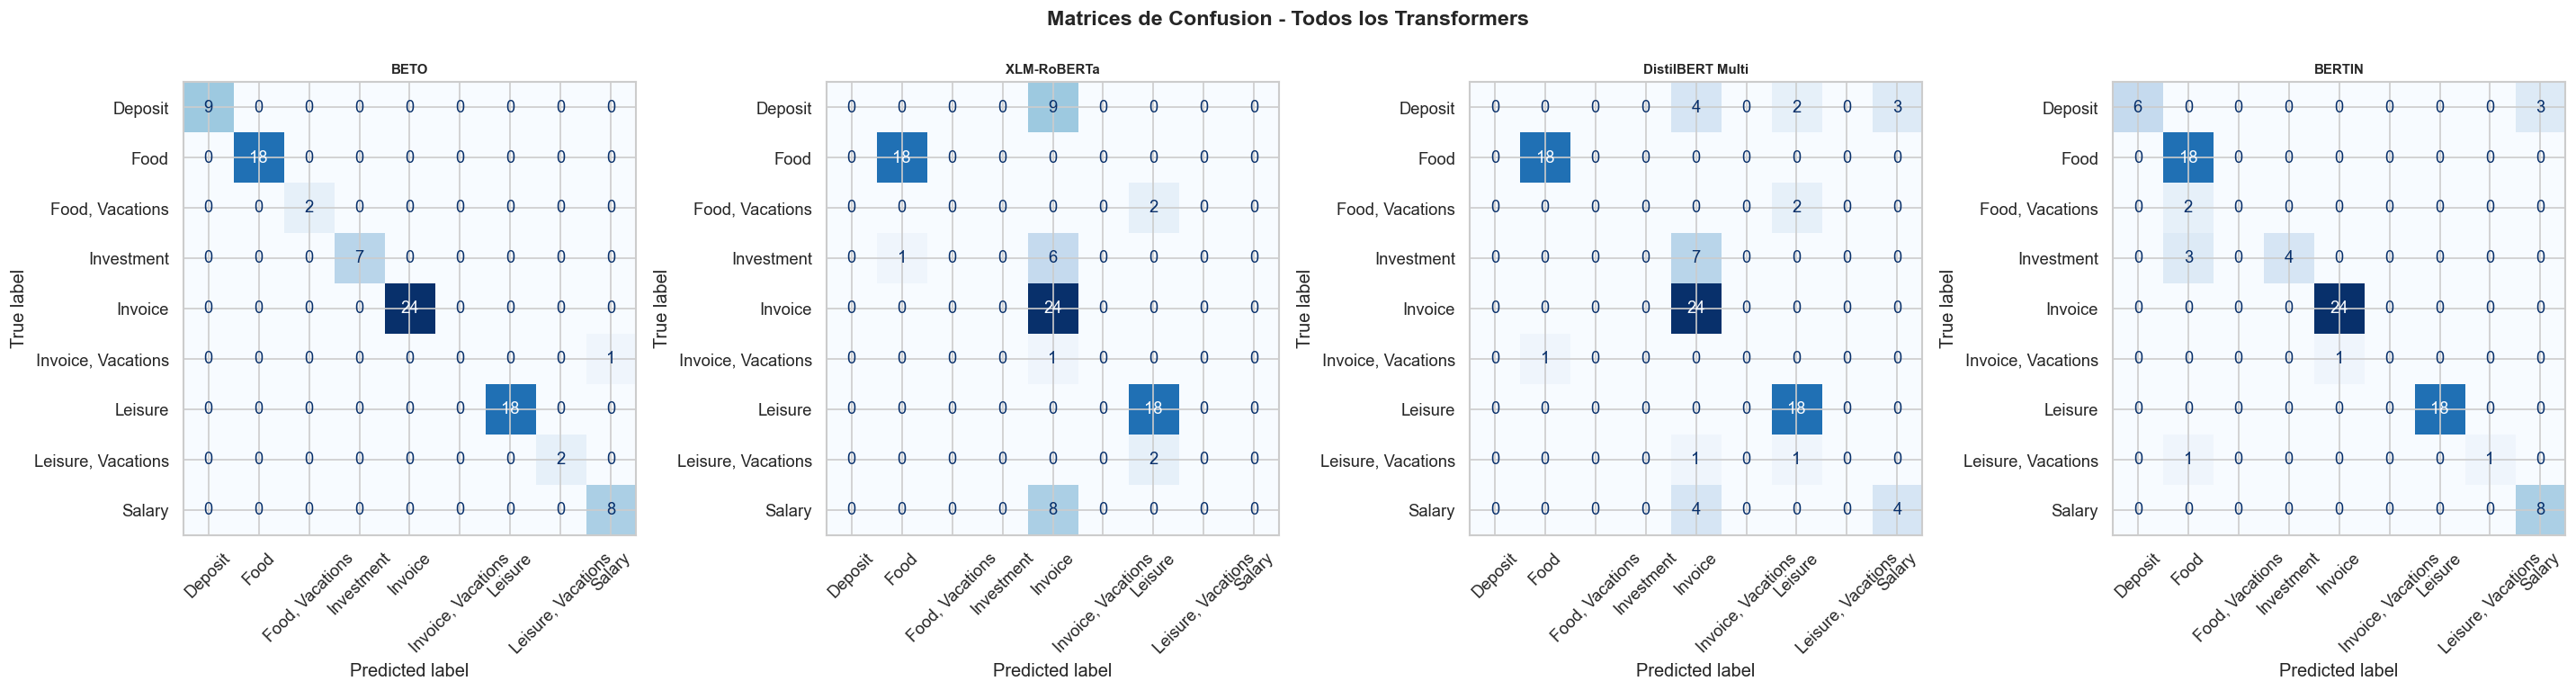

Grafico guardado: matrices_confusion_transformers.png


In [16]:
# Matrices de confusion de todos los modelos
n_models = len(all_results)
if n_models > 0:
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 6))
    if n_models == 1:
        axes = [axes]

    for ax, (name, res) in zip(axes, all_results.items()):
        y_pred = res["y_pred"]
        cm = confusion_matrix(y_true, y_pred, labels=labels_sorted)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
        disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False, xticks_rotation=45)
        ax.set_title(name, fontweight="bold", fontsize=9)

    plt.suptitle("Matrices de Confusion - Todos los Transformers", fontweight="bold", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("matrices_confusion_transformers.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Grafico guardado: matrices_confusion_transformers.png")

## 10. Classification Report del Mejor Modelo

In [17]:
print(f"MEJOR MODELO: {best_name}\n")
print("=" * 70)
print(classification_report(
    y_true, y_pred_best,
    labels=labels_sorted,
    target_names=label_names,
    digits=4,
))
print("=" * 70)

MEJOR MODELO: BETO

                    precision    recall  f1-score   support

           Deposit     1.0000    1.0000    1.0000         9
              Food     1.0000    1.0000    1.0000        18
   Food, Vacations     1.0000    1.0000    1.0000         2
        Investment     1.0000    1.0000    1.0000         7
           Invoice     1.0000    1.0000    1.0000        24
Invoice, Vacations     0.0000    0.0000    0.0000         1
           Leisure     1.0000    1.0000    1.0000        18
Leisure, Vacations     1.0000    1.0000    1.0000         2
            Salary     0.8889    1.0000    0.9412         8

          accuracy                         0.9888        89
         macro avg     0.8765    0.8889    0.8824        89
      weighted avg     0.9788    0.9888    0.9835        89



## 11. Análisis de Errores

In [18]:
y_true_labels = le.inverse_transform(y_true)
y_pred_labels = le.inverse_transform(y_pred_best)

df_eval = pd.DataFrame({
    "Description": df_test["Description"].values,
    "Real": y_true_labels,
    "Prediccion": y_pred_labels,
})
df_errors = df_eval[df_eval["Real"] != df_eval["Prediccion"]]

print(f"Errores del mejor modelo ({best_name}):")
print(f"  Total errores: {len(df_errors)} de {len(df_eval)} ({100*len(df_errors)/len(df_eval):.1f}%)\n")

if len(df_errors) > 0:
    display(df_errors.sort_values("Real").reset_index(drop=True))
else:
    print("  Sin errores. El modelo clasifico todas las muestras correctamente.")

Errores del mejor modelo (BETO):
  Total errores: 1 de 89 (1.1%)



,Description,Real,Prediccion
0,Cargo por servicio contratado durante las vaca...,"Invoice, Vacations",Salary


Errores agrupados por clase real -> prediccion:



,Real,Prediccion,Count
0,"Invoice, Vacations",Salary,1


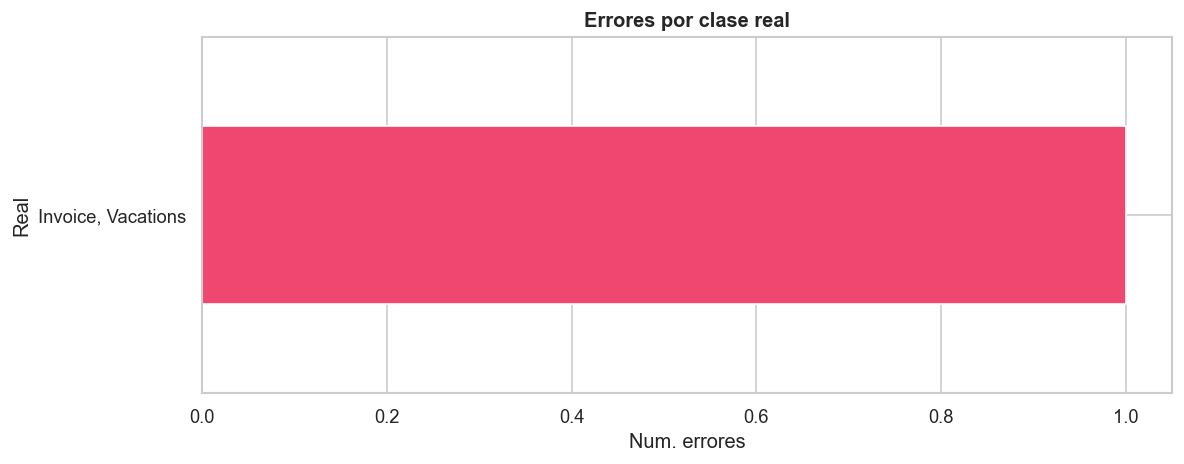

In [19]:
# Resumen de errores por clase
if len(df_errors) > 0:
    print("Errores agrupados por clase real -> prediccion:\n")
    error_summary = df_errors.groupby(["Real", "Prediccion"]).size().reset_index(name="Count")
    error_summary = error_summary.sort_values("Count", ascending=False)
    display(error_summary)

    fig, ax = plt.subplots(figsize=(10, 4))
    errors_by_class = df_errors["Real"].value_counts()
    errors_by_class.plot(kind="barh", ax=ax, color="#ef476f", edgecolor="white")
    ax.set_title("Errores por clase real", fontweight="bold")
    ax.set_xlabel("Num. errores")
    plt.tight_layout()
    plt.show()

## 12. Prueba con Nuevas Descripciones

In [20]:
best_tokenizer = all_results[best_name]["tokenizer"]
best_model = all_results[best_name]["model"]
best_model.eval()

nuevas_descripciones = [
    "Nomina mensual",
    "Compra supermercado",
    "Factura servicio",
    "Ingreso deposito",
    "Pequeno ocio",
    "Pequeno ingreso",
    "Entretenimiento",
    "Inversion mensual",
    "Gasto vacaciones",
    "Gasto alimentacion",
    "Factura importante",
    "Actividad ocio",
    "Aportacion inversion",
    "Microfactura",
    "Viaje o vacaciones",
]

preds = []
with torch.no_grad():
    for desc in nuevas_descripciones:
        inputs = best_tokenizer(
            desc, return_tensors="pt", padding="max_length",
            truncation=True, max_length=MAX_LENGTH,
        ).to(best_model.device)
        outputs = best_model(**inputs)
        pred_id = torch.argmax(outputs.logits, dim=-1).item()
        preds.append(id2label[pred_id])

df_nuevas = pd.DataFrame({
    "Descripcion": nuevas_descripciones,
    "Area predicha": preds,
})

print(f"Predicciones con {best_name}:\n")
display(df_nuevas)

Predicciones con BETO:



,Descripcion,Area predicha
0,Nomina mensual,Salary
1,Compra supermercado,Food
2,Factura servicio,Invoice
3,Ingreso deposito,Deposit
4,Pequeno ocio,Food
5,Pequeno ingreso,Deposit
6,Entretenimiento,Leisure
7,Inversion mensual,Investment
8,Gasto vacaciones,Salary
9,Gasto alimentacion,Food


## 13. Comparativa: Transformers vs Modelos Clásicos

Referencia de los resultados clásicos (del notebook `nlp_area_classifier.ipynb`).

In [21]:
print("Comparativa rapida (Transformers vs Clasicos):")
print()
print("Modelos CLASICOS (TF-IDF + ML):")
print("  Todos alcanzan ~1.0000 F1 (las descripciones son muy discriminativas)")
print()
print("Modelos TRANSFORMER (fine-tuned):")
for _, row in df_results.iterrows():
    print(f"  {row['Modelo']:20s} -> F1: {row['Test F1']:.4f}  (Tiempo: {row['Tiempo (s)']:.0f}s)")
print()
print("Nota: En datasets pequenos y con vocabulario muy predictivo,")
print("los modelos clasicos TF-IDF pueden igualar o superar a los Transformers")
print("con mucho menos coste computacional. Los Transformers brillan en")
print("datasets mas grandes, ambiguos y con mayor diversidad linguistica.")

Comparativa rapida (Transformers vs Clasicos):

Modelos CLASICOS (TF-IDF + ML):
  Todos alcanzan ~1.0000 F1 (las descripciones son muy discriminativas)

Modelos TRANSFORMER (fine-tuned):
  BETO                 -> F1: 0.9835  (Tiempo: 315s)
  BERTIN               -> F1: 0.8685  (Tiempo: 306s)
  DistilBERT Multi     -> F1: 0.6246  (Tiempo: 227s)
  XLM-RoBERTa          -> F1: 0.5586  (Tiempo: 473s)

Nota: En datasets pequenos y con vocabulario muy predictivo,
los modelos clasicos TF-IDF pueden igualar o superar a los Transformers
con mucho menos coste computacional. Los Transformers brillan en
datasets mas grandes, ambiguos y con mayor diversidad linguistica.


## 14. Resumen y Conclusiones

In [22]:
print("=" * 60)
print("          RESUMEN FINAL")
print("=" * 60)
print(f"\nDataset: {df.shape[0]} muestras (Description -> Area)")
print(f"Clases: {NUM_LABELS} areas distintas")
print(f"Split: 80% train ({len(df_train)}) / 20% test ({len(df_test)})")
print(f"Modelos entrenados: {len(all_results)}/{len(MODELS)}")
print(f"Dispositivo: {DEVICE}")
print(f"\nMejor modelo: {best_name}")
print(f"  -> Test F1-Score:  {df_results.iloc[0]['Test F1']:.4f}")
print(f"  -> Test Accuracy:  {df_results.iloc[0]['Test Accuracy']:.4f}")
print(f"  -> Test Precision: {df_results.iloc[0]['Test Precision']:.4f}")
print(f"  -> Test Recall:    {df_results.iloc[0]['Test Recall']:.4f}")
print(f"\nConfiguracion de fine-tuning:")
print(f"  - Epocas: {EPOCHS}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Max tokens: {MAX_LENGTH}")
print("\n" + "=" * 60)

          RESUMEN FINAL

Dataset: 442 muestras (Description -> Area)
Clases: 9 areas distintas
Split: 80% train (353) / 20% test (89)
Modelos entrenados: 4/5
Dispositivo: cpu

Mejor modelo: BETO
  -> Test F1-Score:  0.9835
  -> Test Accuracy:  0.9888
  -> Test Precision: 0.9788
  -> Test Recall:    0.9888

Configuracion de fine-tuning:
  - Epocas: 3
  - Batch size: 16
  - Learning rate: 2e-05
  - Max tokens: 64



## 15. Limpieza (Opcional)

Eliminar los checkpoints y carpetas de resultados generadas durante el entrenamiento.

In [23]:
# Descomentar para limpiar los checkpoints:
# import shutil
# for model_name in MODELS:
#     d = f"./results_{model_name.lower().replace(' ', '_')}"
#     if os.path.exists(d):
#         shutil.rmtree(d)
#         print(f"Eliminado: {d}")
# print("Limpieza completada")